In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
movie=pd.read_csv('movie_preprocessed.csv')
movie.head()

,Unnamed: 0,budget,genres,id,keywords,original_language,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,status,tagline,title,vote_average,vote_count
0,0,15000000.0,"Action,Adventure,Fantasy,Science Fiction",19995.0,"culture clash,future,space war,space colony,so...",en,"In the 22nd century, a paraplegic Marine is di...",12.921594,"Ingenious Film Partners,Twentieth Century Fox ...","United States of America,United Kingdom",10-12-2009,19170001.0,103.0,Released,Enter the World of Pandora.,Avatar,7.2,235.0
1,1,15000000.0,"Adventure,Fantasy,Action",285.0,"ocean,drug abuse,exotic island,east india trad...",en,"Captain Barbossa, long believed to be dead, ha...",12.921594,"Walt Disney Pictures,Jerry Bruckheimer Films,S...",United States of America,19-05-2007,19170001.0,103.0,Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,235.0
2,2,15000000.0,"Action,Adventure,Crime",14629.0,"spy,based on novel,secret agent,sequel,mi6,bri...",en,A cryptic message from Bond’s past sends him o...,12.921594,"Columbia Pictures,Danjaq,B24","United Kingdom,United States of America",26-10-2015,19170001.0,148.0,Released,A Plan No One Escapes,Spectre,6.3,235.0
3,3,15000000.0,"Action,Crime,Drama,Thriller",49026.0,"dc comics,crime fighter,terrorist,secret ident...",en,Following the death of District Attorney Harve...,12.921594,"Legendary Pictures,Warner Bros,DC Entertainmen...",United States of America,16-07-2012,19170001.0,103.0,Released,The Legend Ends,The Dark Knight Rises,7.6,235.0
4,4,15000000.0,"Action,Adventure,Science Fiction",49529.0,"based on novel,mars,medallion,space travel,pri...",en,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,07-03-2012,19170001.0,132.0,Released,"Lost in our world, found in another.",John Carter,6.1,235.0


In [3]:
movie.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
credit=pd.read_csv('credit_preprocessed.csv')
credit.head()

,Unnamed: 0,movie_id,title,cast,director,editor,production_design,art_direction,costume_design,original_music_composer,director_of_photography
0,0,19995,Avatar,"Sam Worthington,Zoe Saldana,Sigourney Weaver,S...",James Cameron,Stephen E. Rivkin,Rick Carter,Andrew Menzies,Deborah Lynn Scott,James Horner,Mauro Fiore
1,1,285,Pirates of the Caribbean At Worlds End,"Johnny Depp,Orlando Bloom,Keira Knightley,Stel...",Gore Verbinski,Stephen E. Rivkin,Rick Heinrichs,John Dexter,Liz Dann,Hans Zimmer,Dariusz Wolski
2,2,206647,Spectre,"Daniel Craig,Christoph Waltz,Léa Seydoux,Ralph...",Sam Mendes,Lee Smith,Dennis Gassner,Neal Callow,Jany Temime,Thomas Newman,Hoyte van Hoytema
3,3,49026,The Dark Knight Rises,"Christian Bale,Michael Caine,Gary Oldman,Anne ...",Christopher Nolan,Lee Smith,Nathan Crowley,Robert Woodruff,Lindy Hemming,Hans Zimmer,Wally Pfister
4,4,49529,John Carter,"Taylor Kitsch,Lynn Collins,Samantha Morton,Wil...",Andrew Stanton,Eric Zumbrunnen,Nathan Crowley,Robert Woodruff,Mayes C. Rubeo,Unknown,Daniel Mindel


In [5]:
credit.drop(columns=['Unnamed: 0'], inplace=True)

# Do most movies get similar ratings from the audience, or are there big differences?

=== Vote_average Sampling Analysis ===
Sample size: 200
Sample mean runtime: 6.28 minutes
Sample standard deviation: 0.83
Population mean runtime: 6.23 minutes


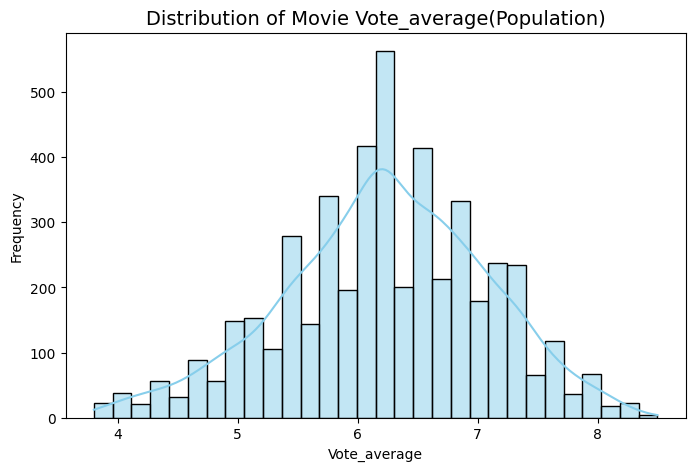

In [6]:
sample_size = 200
sample = movie['vote_average'].sample(sample_size, random_state=42)
sample_mean = sample.mean()
sample_std = sample.std()
population_mean = movie['vote_average'].mean()

print("=== Vote_average Sampling Analysis ===")
print(f"Sample size: {sample_size}")
print(f"Sample mean runtime: {sample_mean:.2f} minutes")
print(f"Sample standard deviation: {sample_std:.2f}")
print(f"Population mean runtime: {population_mean:.2f} minutes")

plt.figure(figsize=(8,5))
sns.histplot(movie['vote_average'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Movie Vote_average(Population)", fontsize=14)
plt.xlabel("Vote_average")
plt.ylabel("Frequency")
plt.show()


# Is there any relation between vote count and vote average

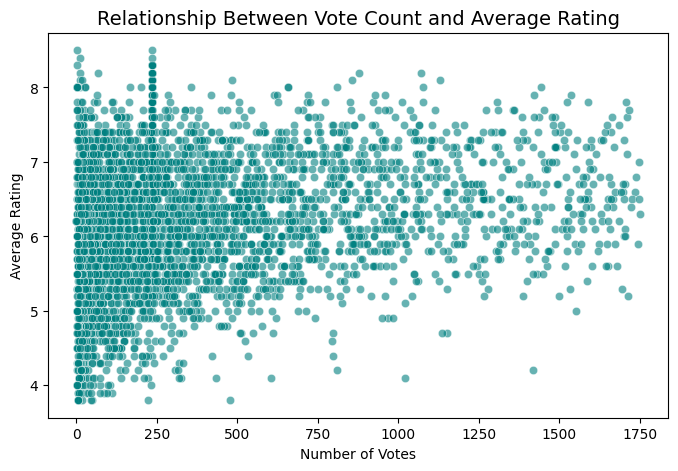

In [7]:

plt.figure(figsize=(8,5))
sns.scatterplot(data=movie, x='vote_count', y='vote_average', alpha=0.6, color='teal')
plt.title('Relationship Between Vote Count and Average Rating', fontsize=14)
plt.xlabel('Number of Votes')
plt.ylabel('Average Rating')
plt.show()


In [8]:
# no relation between vote average and vote count

# Central limit theorem for vote_average

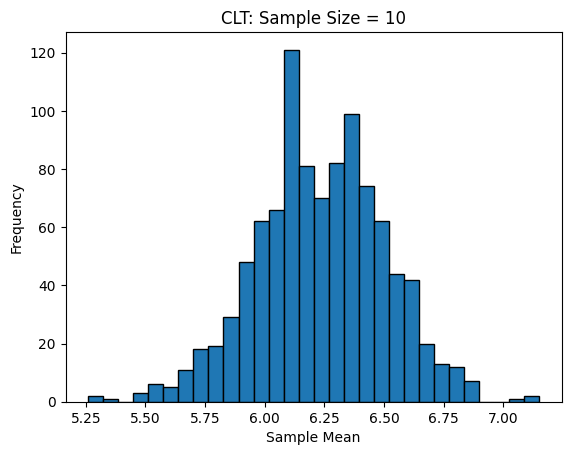

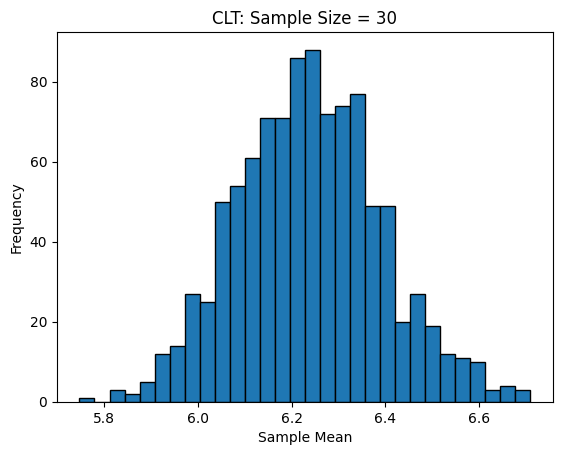

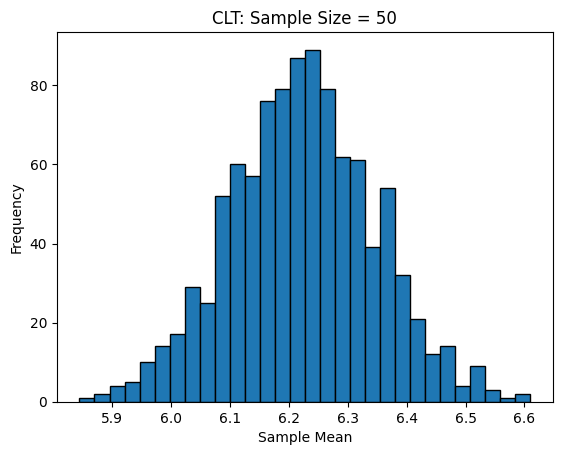

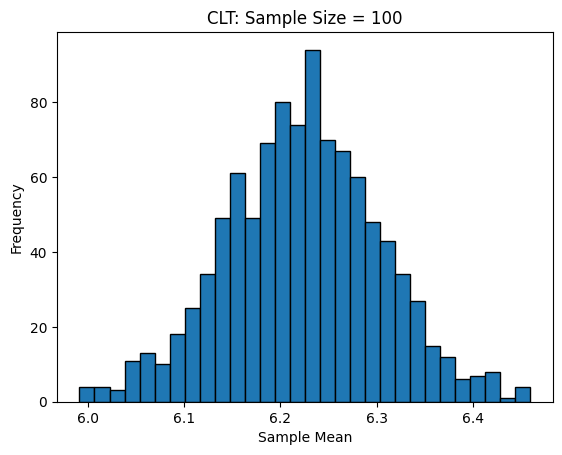

In [9]:
votes = movie['vote_average'].dropna()

def clt_plot(sample_size):
    means = []
    for _ in range(1000):              
        sample = votes.sample(sample_size, replace=True)
        means.append(sample.mean())
    
    plt.hist(means, bins=30, edgecolor='black')
    plt.title(f"CLT: Sample Size = {sample_size}")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.show()

clt_plot(10)
clt_plot(30)
clt_plot(50)
clt_plot(100)


# Do Action movies receive higher average audience ratings than the overall movie average

In [10]:
overall_ratings = movie['vote_average']
action_ratings = movie[movie['genres'].str.contains('Action', case=False, na=False)]['vote_average'].dropna()
mu_0 = overall_ratings.mean()
s = action_ratings
n = s.shape[0]
sample_mean = s.mean()
sample_std = s.std(ddof=1)


t_stat = (sample_mean - mu_0) / (sample_std / np.sqrt(n))
df = n - 1

p_value = stats.t.sf(t_stat, df)  

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha, df)

print("=== T-Test: Are Action Movie Ratings Higher Than Overall Ratings? ===")
print(f"Overall mean rating (µ0): {mu_0:.3f}")
print(f"Action movie mean rating: {sample_mean:.3f}")
print(f"Sample size (n): {n}")
print(f"t-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {df}")
print(f"p-value: {p_value:.6f}")
print(f"Critical t-value (one-tailed): {t_crit:.4f}")


if t_stat > t_crit:
    print("\nConclusion: Reject H₀ → Action movies have statistically higher ratings.")
else:
    print("\nConclusion: Fail to reject H₀ → No evidence that Action movies are rated higher.")


=== T-Test: Are Action Movie Ratings Higher Than Overall Ratings? ===
Overall mean rating (µ0): 6.226
Action movie mean rating: 6.081
Sample size (n): 1154
t-statistic: -5.9856
Degrees of freedom: 1153
p-value: 1.000000
Critical t-value (one-tailed): 1.6462

Conclusion: Fail to reject H₀ → No evidence that Action movies are rated higher.
